# Introducción a la Ciencia de Datos: Tarea 1

Este notebook contiene el código de base para realizar la Tarea 1 del curso. Puede copiarlo en su propio repositorio y trabajar sobre el mismo.
Las **instrucciones para ejecutar el notebook** están en la [página inicial del repositorio](https://gitlab.fing.edu.uy/maestria-cdaa/intro-cd).

Se utiliza el lenguaje Python y la librería Pandas. Si no tiene ninguna familiaridad con la librería, se recomienda realizar algún tutorial introductorio (ver debajo).
También se espera que los alumnos sean proactivos a la hora de consultar las documentaciones de las librerías y del lenguaje, para entender el código provisto.
Además de los recursos provistos en la [página del curso](https://eva.fing.edu.uy/course/view.php?id=1378&section=1), los siguientes recursos le pueden resultar interesantes:
 - [Pandas getting started](https://pandas.pydata.org/docs/getting_started/index.html#getting-started) y [10 minutes to pandas](https://pandas.pydata.org/docs/user_guide/10min.html): Son parte de la documentación en la página oficial de Pandas.
 - [Kaggle Learn](https://www.kaggle.com/learn): Incluye tutoriales de Python y Pandas.


Si desea utilizar el lenguaje R y está dispuesto a no utilizar (o traducir) este código de base, también puede hacerlo.

En cualquier caso, **se espera que no sea necesario revisar el código para corregir la tarea**, ya que todos los resultados y análisis relevantes deberían estar en el **informe en formato PDF**.

## Cargar bibliotecas (dependencias)
Recuerde instalar los requerimientos (`requirements.txt`) en el mismo entorno donde está ejecutando este notebook (ver [README](https://github.com/DonBraulio/introCD)).

In [87]:
from time import time
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import nltk
import wordcloud
from datasets import load_dataset

## Descarga del dataset
En esta tarea se utilizará una base de datos abierta que contiene artículos de noticias publicados en distintos medios de prensa, con la finalidad de realizar una clasificación de textos según el medio de prensa al que pertenecen. [Link](https://huggingface.co/datasets/rjac/all-the-news-2-1-Component-one?utm_source=chatgpt.com) \
\
Ejecute la siguiente celda para descargar los datos y cargarlos en un dataframe de pandas. La constante `DATA_PATH` determina la ubicación donde se almacenaran los datos. \
\
El dataset entero pesa ~8.3gb. Para evitar demoras en la descarga/procesamiento vamos a utilizar el parámetro `streaming=True` y hacer un muestreo aleatorio para descargar una porción de los datos lo más representativa posible.

In [95]:
ds = load_dataset("tomas-gr/all-the-news-2-1-Component-one-sampled", split="train",cache_dir="../data")
df = ds.to_pandas()

## Lectura de Datos

In [ ]:
# Veamos las primeras filas del DataFrame
df.head(10)

# Imprimir publicaciones que empiecen con "Book Review of"
book_reviews = df[df['title'].str.startswith("Book Review of", na=False)]
print(f"Cantidad de publicaciones que empiezan con 'Book Review of': {len(book_reviews)}")
display(book_reviews.head(6))

# # Publicaciones con titulos duplicados:
# duplicates =df[df.duplicated(subset=['title'], keep=False)].sort_values(by='title')
# print(f"Cantidad de artículos con títulos duplicados: {len(duplicates)}")
# display(duplicates.head(6))

# # Articulos con contenido duplicado:
# duplicates = df[df.duplicated(subset=['article'], keep=False) & df['article'].notna()].sort_values(by='article')
# print(f"Cantidad de artículos con contenido duplicado: {len(duplicates)}")
# display(duplicates.head(6))

# # Articulos con misma fecha, titulo y contenido:
# duplicates = df[df.duplicated(subset=['date', 'title', 'article'], keep=False) & df['article'].notna()].sort_values(by=['date', 'title', 'article'])
# print(f"Cantidad de artículos con misma fecha, título y contenido: {len(duplicates)}")
# display(duplicates.head(6))

Cantidad de artículos con títulos duplicados: 418


,idx,article_idx,date,year,month,day,author,title,article,url,section,publication
10607,10608,10608,2019-11-29 00:00:00,2019,11.0,29,NaN,& Other Stories +,NaN,https://www.refinery29.com/en-us/shop/product/belted-wool-blend-long-coat-8922705,NaN,Refinery 29
20535,20536,20536,2019-12-01 00:00:00,2019,12.0,1,NaN,& Other Stories +,NaN,https://www.refinery29.com/en-us/shop/product/chunky-alpaca-blend-knitted-sweater-2-8936731,NaN,Refinery 29
9125,9126,9126,2018-11-24 05:00:01,2018,11.0,24,Kathleen Massara,11 of Our Best Weekend Reads,"Welcome to the weekend. In between Thanksgiving leftovers and home projects, make time for some great journalism. “New Yorkers do love a parade,” John Leland writes, “and where New Yorkers gather, New York Times photographers follow.” (See the photos of this year’s parade, on a day that tied for the second-coldest Thanksgiving in New York City’s history.) Metro _____ The country is host to a supernova of creative expression — in short videos, podcasts, blogs and streaming TV — that ought to dispel any notions of Chinese culture as drearily conformist. International_____ The Supreme Court’s leader broke from his studied restraint and responded to President Trump’s criticism of a federal judge, suggesting Mr. Trump had a profound misunderstanding of the courts’ role. Washington _____ Inmates expose themselves and threaten rape. Male guards let them do it. And women who complain are “pretty much blackballed,” one correctional officer said. National_____ Washi is to the Japanese something like what wine is to the French — a national obsession and point of pride. T Magazine_____ A decade ago, the United States mandated the use of vegetable oil in biofuels, leading to industrial-scale deforestation — and a huge spike in carbon emissions. Magazine_____ John Allen Chau had ventured to North Sentinel in the Andaman Sea, where the local tribe has killed outsiders for setting foot on their shore. International _____ The surge in popularity of services such as 23andMe means that more and more people are unearthing long-buried connections and surprises in their ancestry. Magazine_____ The year’s noteworthy fiction, poetry and nonfiction, selected by the editors of The New York Times Book Review. Book Review_____ The locals, known as porteños, take their drinking traditions — and the amazing variety of places where they can indulge them — very seriously. Travel _____ An oral history of Barry Jenkins’s “Medicine for Melancholy,” as told by admirers — Lena Waithe, Justin Simien...",https://www.nytimes.com/2018/11/24/arts/11-of-our-best-weekend-reads.html,arts,The New York Times
29439,29440,29440,2018-06-02 05:00:13,2018,6.0,2,Remy Tumin,11 of Our Best Weekend Reads,"June, glorious, June! That sweet tease of summer. It’s time to make your reading plans (we’ve got you covered), set summer resolutions and enjoy those extra long days. But first, take the weekend to catch up on some great reads you may have missed. Disappear into a thriller, a romance, a cookbook or the great outdoors: We’ve got them and more in our summer reading guide. Book Review ____ After Mr. Freeman spoke to the CNN reporter Chloe Melas in a way she considered inappropriate, she tracked down other women who said the actor had mistreated them. Culture ____ Plastics and papers from dozens of American cities and towns are being dumped in landfills after China stopped recycling most “foreign garbage.” “All of a sudden, material being collected on the street doesn’t have a place to go,” said Pete Keller, vice president of recycling and sustainability at Republic Services, one of the largest waste managers in the country. Here’s a guide to recycling. First lesson: Don’t recycle greasy pizza boxes. Climate ____ When you’re not sitting across from someone, you’re sitting across from the world. Why should a meal on your own be uninspired or scarfed down as if consumed on the shoulder of an interstate highway? Our writer explores the joys of a table for one i

Cantidad de artículos con contenido duplicado: 136


,idx,article_idx,date,year,month,day,author,title,article,url,section,publication
7651,7652,7652,2016-02-01 00:00:00,2016,2.0,1,Tal Kopan,"Iowa caucuses live updates: Hillary Clinton declared winner, Donald Trump reacts to loss",,https://www.cnn.com/2016/02/01/politics/iowa-caucuses-updates-real-time/index.html,politics,CNN
22381,22382,22382,2016-10-11 17:49:00,2016,10.0,11,Kelli Bender,Postal Worker for USPS Sprays Florida Dog with Tear Gas,,https://people.com/pets/postal-worker-uses-tear-gas-on-dog-claims-it-was-in-self-defense/,pets,People
27846,27847,27847,2019-07-29,2019,7.0,29,Brenna Williams,US politics quiz,,https://www.cnn.com/2019/07/29/politics/the-point-political-pop-quiz/index.html,politics,CNN
28601,28602,28602,2019-01-23,2019,1.0,23,NaN,Pelosi says State of the Union won't happen during shutdown,,https://www.cnn.com/2019/01/23/politics/pelosis-letter-to-trump/index.html,politics,CNN
5482,5483,5483,2019-02-05,2019,2.0,5,Matthew Sheffield,"What America’s Thinking: February 5, 2019 | TheHill","An overwhelming majority of voters are concerned that the U.S. will enter a recession in 2020, according to a Hill-HarrisX poll released Monday. A majority of Republican voters -- 62 percent -- identify as both fiscally and socially conservative, according to a new Hill-HarrisX poll released on Friday. More than half of voters would not consider reelecting President Trump in 2020, according to a new poll released on Thursday. Top-tier candidates, including former Vice President Joe Biden and Sen. Two-thirds of voters said in a poll released Tuesday that President Trump’s next round of China tariffs will increase prices on U.S. consumer goods. Mental illness, weak gun laws and hateful public rhetoric are largely to blame for mass shootings in the United States, according to a new Hill-HarrisX poll. Just over half of Republicans — 51 percent — said in a new Hill-HarrisX poll that the federal deficit is a problem that the government needs to deal with immediately. Less than half of U.S. voters trust companies headquartered in Mexico and China, according to a new Hill-HarrisX poll. President Trump’s job approval rating has dropped six points among voters between the ages of 18 and 34 in the latest Hill-HarrisX poll. A plurality of voters — 44 percent — say they think President Trump responds more fiercely to critics who aren’t white, according to a Hill-HarrisX poll released on Tuesday. Almost half of voters polled — 47 percent — say there was no clear winner from last week’s Democratic presidential primary debate in Detroit, according to a new Hill-HarrisX poll. Twenty-seven percent of Americans said that they thought the latest two-year budget deal would have no impact on their financial situation, according to a new poll out Friday. Support for impeachment proceedings against President Trump has slipped among Democratic voters following special counsel Robert Mueller’s public testimony before Congress last week, according to a poll released on Thursday. The H...",https://thehill.com/hilltv/what-americas-thinking/428541-what-americas-thinking-february-5-2019,NaN,The Hill
16281,16282,16282,2019-03-07,2019,3.0,7,Matthew Sheffield,"What America's Thinking: March 7, 2019 | TheHill","An overwhelming majority of voters are concerned that the U.S. will enter a recession in 2020, according to a Hill-HarrisX poll released Monday. A majority of Republican voters -- 62 percent -- identify as both fiscally and socially conservative, according to a new Hill-HarrisX poll released on Friday. More than half of voters would not consider reelecting President Trump in 2020, according to a new poll released on Thursday. Top-tier candidates, including former Vice President Joe Biden and Sen. Two-thirds of voters said in a poll released Tuesday that President Trump’s next round of China tariffs will increase prices on U.S. consumer goods. Mental illness, weak gun laws and hateful public rhetoric are largely to blame for mass shootings in the United 

Cantidad de artículos con misma fecha, título y contenido: 18


,idx,article_idx,date,year,month,day,author,title,article,url,section,publication
1382,1383,1383,2018-07-30,2018,7.0,30,"Tom Sims, Huw Jones",Deutsche Bank shifts euro clearing as post-Brexit landscape emerges,"FRANKFURT/LONDON (Reuters) - Deutsche Bank (DBKGn.DE) has moved the clearing of a “large part” of new euro-denominated derivatives trades from London to Frankfurt, as financial firms ramp up their Brexit preparations. The shift by Germany’s largest bank, which was confirmed by a spokesman on Monday, is a boost to Deutsche Boerse’s (DB1Gn.DE) efforts to gain ground from London in the euro clearing market. This ensures a deal completes even if one side of a trade goes bust, as Britain exits the European Union. London Stock Exchange’s (LSE.L) LCH division has long dominated clearing of euro-denominated derivatives like interest rate swaps, which are used by companies to cover themselves against unexpected moves in borrowing costs. The worry for the City of London is that if chunks of clearing move elsewhere, other activities like trading and jobs could follow, eating away at Britain’s biggest economic sector. LSE declined to comment on Deutsche Bank’s largely symbolic move, first reported by the Financial Times, which was widely expected given that its base is in Frankfurt and it is moving other activities there due to Brexit. The Deutsche Bank spokesman said no jobs were being transferred and that the bank was effectively pushing a different button to route the clearing to Eurex, Deutsche Boerse’s clearing division, rather than LCH. International banks with European bases in London have been opening hubs in the EU to avoid Brexit disrupting business. Meanwhile trading firm Jane Street, one of the largest players in exchange-traded funds, said on Monday it had opened an office in Amsterdam, giving it a location from which to serve EU clients when Britian leaves the bloc. [L5N1UQ402] The Dutch capital, with high-speed digital infrastructure in the heart of Western Europe, has become a favourite destination for trading businesses looking for an alternative to London. And Credit Suisse (CSGN.S) is looking to shift about 50 jobs from London to Madrid as part of its eff...",https://www.reuters.com/article/us-britain-eu-deutsche-clearing/deutsche-bank-shifts-euro-clearing-as-post-brexit-landscape-emerges-idUSKBN1KK0UA,Business News,Reuters
7150,7151,7151,2018-07-30,2018,7.0,30,"Tom Sims, Huw Jones",Deutsche Bank shifts euro clearing as post-Brexit landscape emerges,"FRANKFURT/LONDON (Reuters) - Deutsche Bank (DBKGn.DE) has moved the clearing of a “large part” of new euro-denominated derivatives trades from London to Frankfurt, as financial firms ramp up their Brexit preparations. The shift by Germany’s largest bank, which was confirmed by a spokesman on Monday, is a boost to Deutsche Boerse’s (DB1Gn.DE) efforts to gain ground from London in the euro clearing market. This ensures a deal completes even if one side of a trade goes bust, as Britain exits the European Union. London Stock Exchange’s (LSE.L) LCH division has long dominated clearing of euro-denominated derivatives like interest rate swaps, which are used by companies to cover themselves against unexpected moves in borrowing costs. The worry for the City of London is that if chunks of clearing move elsewhere, other activities like trading and jobs could follow, eating away at Britain’s biggest economic sector. LSE declined to comment on Deutsche Bank’s largely symbolic move, first reported by the Financial Times, which was widely expected given that its base is in Frankfurt and it is moving other activities there due to Brexit. The Deutsche Bank spokesman said no jobs were being transferred and that the bank was effectively pushing a different button to route the clearing to Eurex, Deutsche Boerse’s clearing division, rather than LCH. International banks with European bases in London have been opening hubs in the EU to avoid Brexit disrupting business. Meanwhile trading 

In [90]:
# Veamos información general del DataFrame
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30213 entries, 0 to 30212
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   idx          30213 non-null  int64
 1   article_idx  30213 non-null  int64
 2   date         30213 non-null  str  
 3   year         30213 non-null  str  
 4   month        30213 non-null  str  
 5   day          30213 non-null  str  
 6   author       18808 non-null  str  
 7   title        30213 non-null  str  
 8   article      29037 non-null  str  
 9   url          30072 non-null  str  
 10  section      19981 non-null  str  
 11  publication  30072 non-null  str  
dtypes: int64(2), str(10)
memory usage: 96.1 MB


# Parte 1: Cargado y Limpieza de Datos

## A. Exploración de Datos
Analice el contenido del DataFrame. Reporte si existen datos faltantes en algún campo, o cualquier otro problema de calidad de datos que encuentre. \
En particular, analice la cantidad de artículos por medio de prensa, y a partir de este punto trabaje con los **cinco medios con mayor cantidad de artículos**.

In [91]:
# TODO: Analice datos faltantes por columna
# Returns a count of missing values for every column
print("Cantidad de datos faltantes por columna:")
df.isna().sum()


Cantidad de datos faltantes por columna:


idx                0
article_idx        0
date               0
year               0
month              0
day                0
author         11405
title              0
article         1176
url              141
section        10232
publication      141
dtype: int64

In [92]:
# TODO: Analice la cantidad de artículos por medio de prensa

# Cantidad de articulos por medio de prensa:
print("Cantidad de artículos por medio de prensa:")
print(df['publication'].value_counts())

# Tome los 5 medios con más artículos
top5 = df['publication'].dropna().value_counts().head(5).index
print('Los 5 medios con más artículos son:')
print(top5)

Cantidad de artículos por medio de prensa:
publication
Reuters               9431
The New York Times    2840
CNBC                  2623
The Hill              2349
People                1528
CNN                   1446
Refinery 29           1236
Vice                  1154
Mashable              1045
Business Insider       660
The Verge              594
TechCrunch             568
TMZ                    552
Vox                    549
Axios                  538
Politico               518
Washington Post        468
Buzzfeed News          376
Gizmodo                329
Economist              303
Wired                  231
Fox News               227
Vice News              187
New Republic           145
Hyperallergic          123
New Yorker              52
Name: count, dtype: int64
Los 5 medios con más artículos son:
Index(['Reuters', 'The New York Times', 'CNBC', 'The Hill', 'People'], dtype='str', name='publication')


## B. Visualización temporal
Genere una gráfica que permita visualizar los artículos de los cinco medios a lo largo del tiempo, con alguna escala temporal adecuada. \
Comente si se identifican momentos de mayor actividad o patrones temporales en la cobertura.

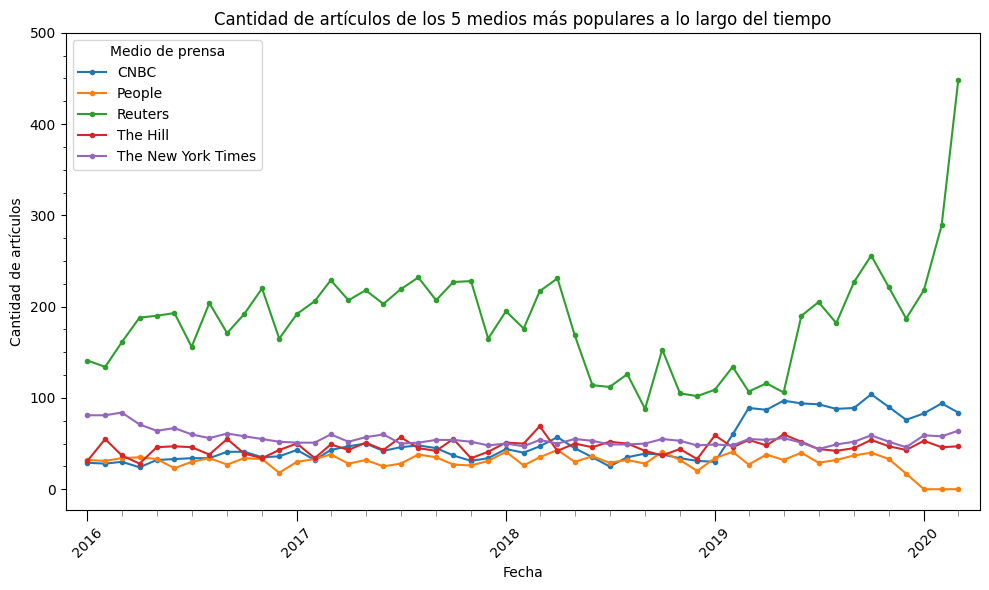

In [93]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
import math

df['date'] = pd.to_datetime(df['date'], errors='coerce', format= 'mixed')
df['date'].isna().sum()

# Recreate df_top_5 after date conversion to ensure dates are datetime objects
df_top_5 = df[df['publication'].isin(top5)]
df_top_5 = df_top_5[df_top_5['date'].notna()]
df_top_5['month'] = df_top_5['date'].dt.to_period('M')

counts = (
    df_top_5
    .groupby(['month', 'publication'])
    .size()
    .unstack(fill_value=0)
)

counts.index = counts.index.to_timestamp()

counts = counts[:-1]

fig, ax = plt.subplots(figsize=(10,6))

# Graficar cada medio
for col in counts.columns:
    ax.plot(
        counts.index,
        counts[col],
        marker='o',
        markersize=3,
        label=col
    )


# Tick principal: cada año
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Tick menor: cada 2 meses
ax.xaxis.set_minor_locator(mdates.MonthLocator(interval=2))

# Mostrar ticks menores
ax.tick_params(axis='x', which='major', length=8)
ax.tick_params(axis='x', which='minor', length=4, color='gray')


# Eje Y fijo de 0 a 500
# ax.set_ylim(0, 500)
y_max = counts.max().max()
ax.set_ylim(-0.05 * y_max, 500)
ax.yaxis.set_major_locator(ticker.MultipleLocator(100))
ax.yaxis.set_minor_locator(ticker.MultipleLocator(25))

x_min = counts.index.min()
x_max = counts.index.max()
x_span = x_max - x_min
x_padding = x_span * 0.025
ax.set_xlim(x_min - x_padding, x_max + x_padding)

# Labels
ax.set_xlabel('Fecha')
ax.set_ylabel('Cantidad de artículos')
ax.set_title('Cantidad de artículos de los 5 medios más populares a lo largo del tiempo')

plt.xticks(rotation=45)
plt.legend(title='Medio de prensa')

plt.tight_layout()
plt.savefig('grafica6meses.pdf', bbox_inches='tight')

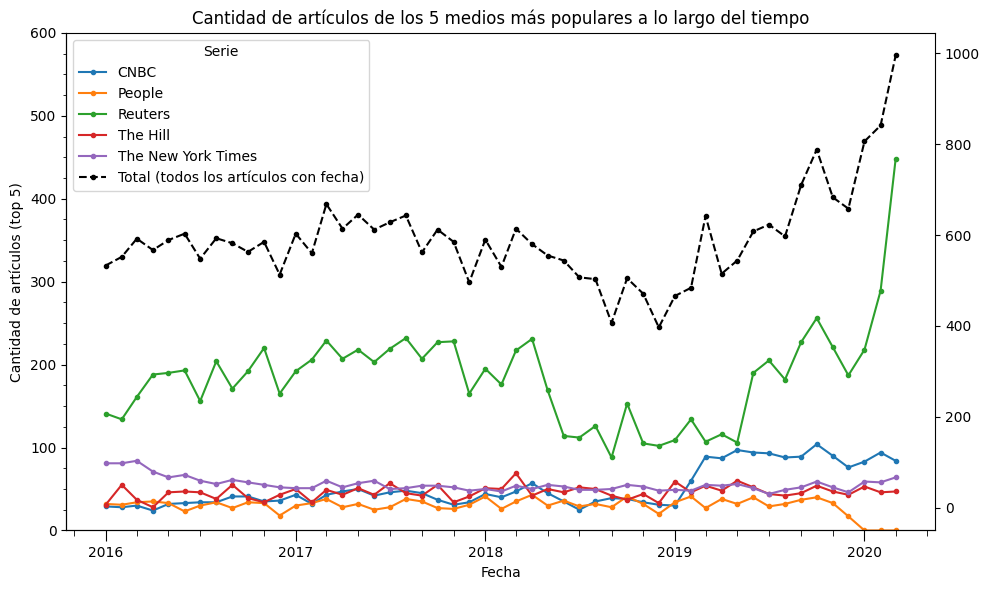

In [94]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
import math

# Asegurarse de que la columna date sea datetimelike antes de usar .dt
if df['date'].dtype == object or not pd.api.types.is_datetime64_any_dtype(df['date']):
    df['date'] = pd.to_datetime(df['date'], errors='coerce', format='mixed')

fig, ax = plt.subplots(figsize=(10,6))

for col in counts.columns:
    ax.plot(
        counts.index,
        counts[col],
        marker='o',
        markersize=3,
        label=col
    )

# Calcular el total de artículos con fecha en todo el dataset (no solo top5)
df_all_with_date = df[df['date'].notna()].copy()
df_all_with_date['month'] = df_all_with_date['date'].dt.to_period('M')
total_counts = df_all_with_date.groupby('month').size().sort_index().to_timestamp()
# Alinear índices con el dataframe de top5 para que las fechas coincidan
total_counts = total_counts.reindex(counts.index, fill_value=0)

ax2 = ax.twinx()
ax2.plot(
    counts.index,
    total_counts,
    marker='o',
    markersize=3,
    label='Total (todos los artículos con fecha)',
    color='black',
    linestyle='--'
)

# ===== EJE Y (0 un poco más arriba) =====
y_max = counts.max().max()
y_max_rounded = math.ceil(y_max / 100) * 100
ax.set_ylim(0, y_max_rounded + 100)
ax.yaxis.set_major_locator(ticker.MultipleLocator(100))
ax.yaxis.set_minor_locator(ticker.MultipleLocator(25))

# Ajustar el eje x con un poco de relleno a izquierda/derecha
x_min = counts.index.min()
x_max = counts.index.max()
x_span = x_max - x_min
x_padding = x_span * 0.05
ax.set_xlim(x_min - x_padding, x_max + x_padding)

# No ajustar el límite del eje derecho al mismo rango del izquierdo;
# el total puede tener una escala diferente.
ax2_max = total_counts.max()
ax2.set_ylim(-0.05 * ax2_max, ax2_max * 1.05)

# ===== EJE X CORRECTO =====
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_minor_locator(mdates.MonthLocator(interval=2))

ax.tick_params(axis='x', which='major', length=8)
ax.tick_params(axis='x', which='minor', length=4)

# sin grid en el eje principal
ax.grid(False)

# estética limpia
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# labels
ax.set_xlabel('Fecha')
ax.set_ylabel('Cantidad de artículos (top 5)')
# ax2.set_ylabel('Total artículos con fecha', color='black')
# ax2.tick_params(axis='y', colors='black')
ax.set_title('Cantidad de artículos de los 5 medios más populares a lo largo del tiempo')

# Combinar leyendas
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines + lines2, labels + labels2, title='Serie', loc='upper left')

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('grafica6mesespunteada.pdf', bbox_inches='tight')
plt.show()

## C. Limpieza de texto y conteo de palabras
Se provee la función `clean_text(...)` que realiza parte de la normalización del texto. \
**Complete la función** agregando signos de puntuación faltantes y cualquier otra normalización que considere oportuna. \
Compruebe el resultado observando el contenido del DataFrame procesado. Comente todas las transformaciones que haya agregado y justifique.

In [ ]:
def clean_text(df, column_name):

    # Eliminar primeras palabras hasta el primer "\n"
    result = df[column_name].str.replace(r"^[^\n]*\n", "", regex=True)

    # Convertir todo a minúsculas
    result = result.str.lower()

    # Handle common contractions before removing punctuation
    result = result.str.replace(r"I'm", "I am", regex=True)
    result = result.str.replace(r"you're", "you are", regex=True)
    result = result.str.replace(r"he's", "he is", regex=True)
    result = result.str.replace(r"she's", "she is", regex=True)
    result = result.str.replace(r"it's", "it is", regex=True)
    result = result.str.replace(r"we're", "we are", regex=True)
    result = result.str.replace(r"they're", "they are", regex=True)
    result = result.str.replace(r"I've", "I have", regex=True)
    result = result.str.replace(r"you've", "you have", regex=True)
    result = result.str.replace(r"we've", "we have", regex=True)
    result = result.str.replace(r"they've", "they have", regex=True)
    result = result.str.replace(r"can't", "cannot", regex=True)
    result = result.str.replace(r"won't", "will not", regex=True)
    result = result.str.replace(r"don't", "do not", regex=True)
    result = result.str.replace(r"doesn't", "does not", regex=True)

    # TODO: completar signos de puntuación faltantes (removed "'" since handled above)
    for punc in ["[", "\n", ",", ":", "?", "!", "(", ")", '"', "]"]:
        result = result.str.replace(punc, " ")

    return result

In [ ]:
# TODO: Aplique clean_text sobre la columna de texto elegida y cree una nueva columna "CleanText"

CleanText = clean_text(df_top_5, "article")

# Add CleanText as a new column to df_top_5
df_top_5['CleanText'] = CleanText
# print(df_top_5['CleanText'].head(n=5))
print(df_top_5.head(n=5))

## D. Elección de campos de texto
Discuta si conviene trabajar con:
- sólo el cuerpo del artículo,
- sólo el título,
- o una combinación de ambos.

Justifique brevemente su decisión.

*TODO: Escriba su análisis en el informe.*

Conviene trabjar con una combinacion de ambos pues la eleccion de palabras es muy importante en el titulo para captar la atencion del lector.

## E. Pistas que identifican al medio de prensa
Analice si en el texto aparecen pistas que identifiquen de manera directa al medio de prensa (nombres del medio, URLs, firmas, nombres de secciones, plantillas repetidas, etc.). \
En caso de encontrarlas, comente si considera conveniente eliminarlas o reducir su impacto, y justifique su decisión.

In [ ]:
# TODO: Explore el texto buscando pistas que identifiquen directamente al medio de prensa
# Por ejemplo, busque nombres de medios, URLs, firmas, etc.

La URL de todos las publicaciones indican el medio de prensa de forma directa.
El formato de la fecha da una indicacion pues cada medio utiliza un formato especifico.
Luego, existen otros indicadores en los titulos y articulos como se ve a continuacion:

In [ ]:
# Reuters

df_reuters = df[df['publication'] == 'Reuters']
print('Number of articles from Reuters: {}'.format(len(df_reuters)))

# En la seccion 'article'
df_reuters_with_word_reuters = df_reuters[df_reuters['article'].str.contains('Reuters', case=False, na=False)]
print('Number of publications from Reuters containing the word "Reuters" in the article: {}'.format(len(df_reuters_with_word_reuters)))

# En la seccion 'title'
df_reuters_with_word_brief = df_reuters[df_reuters['title'].str.contains('brief', case=False, na=False)]
print('Number of publications from Reuters containing the word "brief" in the title: {}'.format(len(df_reuters_with_word_brief)))

# Publicaciones con la palabra "Reuters" en el artículo y "brief" en el título

print('Articles from Reuters containing the word "Reuters" in the article')
display(df_reuters_with_word_reuters)

print('Articles from Reuters containing the word "brief" in the title')
display(df_reuters_with_word_brief)

In [ ]:
# People

df_people = df[df['publication'] == 'People']
display(df_people)

In [ ]:
# CNBC
# Configure pandas to show full text content
pd.set_option('display.max_colwidth', 100)

df_cnbc = df[df['publication'] == 'CNBC']
# display(df_cnbc)

display(df_cnbc['article'])
display(len(df_cnbc))
df_cnbc_with_no_author = df_cnbc[df_cnbc['author'].isna()]
display(len(df_cnbc_with_no_author))

## F. Restricción por sección o período temporal
Evalúe si conviene restringir el análisis a artículos de una misma sección temática o de un período temporal acotado, con el objetivo de reducir el efecto del tema sobre una futura tarea de clasificación por medio. \
No es necesario implementar esta restricción, pero sí discutir sus posibles ventajas y desventajas.

*TODO: Escriba su análisis en el informe.*

Si nuestro objetivo es crear un clasificador, conviene distinguir los articulos por tematica o periodo temporal. De lo contrario el clasificador podr'ia sesgarse e identificar siempre los articulos de una tematica o periodo a un determinado medio.
Lo ideal seria comparar articulos de una misma tematica o periodo temporal para entrenar a un clasificador.

# Parte 2: Conteo de Palabras y Visualizaciones

## A. Palabras más frecuentes por medio
Realice una visualización que permita comparar las palabras más frecuentes de cada uno de los cinco medios de prensa. \
Sin necesidad de implementarlo, proponga ideas para modificar esta visualización con el fin de encontrar diferencias entre secciones temáticas, fechas, o tipos de noticias.

In [ ]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from collections import Counter
import matplotlib.pyplot as plt
from wordcloud import WordCloud # Added to ensure WordCloud is imported

# Descargar recursos necesarios de nltk (solo la primera vez)
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab') # Added to fix the LookupError

# Función para obtener palabras más frecuentes
def get_most_frequent_words(text_series, n=20):
    # Combinar todo el texto
    all_text = ' '.join(text_series.dropna())

    # Tokenizar
    tokens = word_tokenize(all_text.lower())

    # Eliminar stopwords
    stop_words = set(stopwords.words('english'))
    filtered_tokens = [word for word in tokens if word.isalnum() and word not in stop_words]

    # Contar frecuencias
    word_freq = Counter(filtered_tokens)

    return word_freq.most_common(n)

# Aplicar a cada medio
for publication in top5:
    df_pub = df_top_5[df_top_5['publication'] == publication]
    frequent_words = get_most_frequent_words(df_pub['CleanText'])

    print(f"\nPalabras más frecuentes en {publication}:")
    for word, freq in frequent_words:
        print(f"{word}: {freq}")

# Visualizacion de las 20 palabras mas frecuentes usando wordcloud, quitando las stopwords y signos de puntuacion

# Create custom stopwords that includes short words from contractions
custom_stopwords = set(stopwords.words('english'))
custom_stopwords.update(['m', 's', 're', 've', 'd', 'll', 't'])  # Short words from contractions

# Crear wordclouds separados para cada medio
for publication in top5:
    # Corrected line: Always filter from the original df_top_5
    df_pub = df_top_5[df_top_5['publication'] == publication]
    all_text = ' '.join(df_pub['CleanText'].dropna())

    # Crear wordcloud con mejores parámetros
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        max_words=20,  # Limitar a las 20 palabras más frecuentes
        colormap='viridis',
        prefer_horizontal=0.8,
        stopwords=custom_stopwords,  # Use custom stopwords with short words filtered
        min_word_length=2  # Exclude single letters like "u", "k", etc.
    ).generate(all_text)

    # Mostrar en figura separada
    plt.figure(figsize=(10, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(f'Word Cloud - {publication}', fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.show()

In [ ]:
###################### Wordcloud toma una sola palabra ##########################################

import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Create custom stopwords that includes short words from contractions
custom_stopwords = set(stopwords.words('english'))
custom_stopwords.update(['m', 's', 're', 've', 'd', 'll', 't'])  # Short words from contractions

# Crear wordclouds separados para cada medio
for publication in top5:
    df_pub = df_top_5[df_top_5['publication'] == publication]
    all_text = ' '.join(df_pub['CleanText'].dropna())

    # Crear wordcloud con `collocations=False` para solo considerar palabras individuales
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        max_words=20,
        colormap='viridis',
        prefer_horizontal=0.8,
        stopwords=custom_stopwords,
        min_word_length=2,
        collocations=False  # <--- Esto es clave para considerar solo palabras individuales
    ).generate(all_text)

    # Mostrar en figura separada
    plt.figure(figsize=(10, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(f'Word Cloud (Single Words Only) - {publication}', fontsize=14, fontweight='bold')
    plt.axis('off')

    # Save the word cloud as a PDF
    plt.savefig(f'wordcloud_{publication.replace(" ", "_")}.pdf', bbox_inches='tight')
    plt.show()

## B. Medios con mayor cantidad de palabras
Corra el código que permite encontrar los medios con mayor cantidad de palabras. \
En caso de encontrar algún problema luego de realizar la visualización, comente a qué se debe y proponga formas de resolverlo.

In [ ]:
####### PARA LOS 5 MEDIOS MAS POPULARES #############################################################

# Imprimir la cantidad de publicaciones totales por medio
for publication in top5:
    count = len(df_top_5[df_top_5['publication'] == publication])
    print(f"Total de publicaciones en {publication}: {count}")

# Imprimir la cantidad de palabras totales por medio
for publication in top5:
    df_pub = df_top_5[df_top_5['publication'] == publication]
    total_words = df_pub['CleanText'].str.split().str.len().sum()
    print(f"Total de palabras en {publication}: {total_words}")

# Imprimir la cantidad promedio de palabras por artículo por medio
for publication in top5:
    df_pub = df_top_5[df_top_5['publication'] == publication]
    avg_words = df_pub['CleanText'].str.split().str.len().mean()
    print(f"Promedio de palabras por artículo en {publication}: {avg_words:.2f}")

In [ ]:
######################### PARA TODOS LOS MEDIOS ########################################################

# First, ensure the 'article' column in the original DataFrame is cleaned
df['CleanText'] = clean_text(df, 'article')

# Get all unique publications
all_publications = df['publication'].dropna().unique()

# Prepare data for the table
word_counts_data = []

# Calculate total words for each publication
for publication in all_publications:
    df_pub_all = df[df['publication'] == publication]
    total_words_all = df_pub_all['CleanText'].str.split().str.len().sum()
    word_counts_data.append({'Publication': publication, 'Total Palabras': total_words_all})

# Create a DataFrame and display it
df_all_word_counts = pd.DataFrame(word_counts_data)
display(df_all_word_counts.sort_values(by='Total Palabras', ascending=False).reset_index(drop=True))

## C. Matriz de menciones entre medios
Construya una matriz de 5×5, donde cada fila y columna corresponden a un medio de prensa, y la entrada (i,j) contiene la cantidad de veces que el medio *i* menciona al medio *j*. \
\
**Opcional:** genere un grafo dirigido con esa matriz de adyacencia para visualizar las menciones. Puede ser útil la biblioteca `networkx`.

In [ ]:
import pandas as pd
import numpy as np
import re

# Create a mapping from original publication names to search terms
# 'People' is capitalized for case-sensitive matching as requested.
search_terms = {
    'Reuters': 'Reuters',
    'The New York Times': 'The New York Times',
    'CNBC': 'CNBC',
    'The Hill': 'The Hill',
    'People': 'People' # Search for 'People' with capital 'P'
}

# Initialize a 5x5 matrix with zeros, with publication names as index and columns
mentions_matrix = pd.DataFrame(0, index=top5, columns=top5)

# Iterate through each source publication (row in the matrix)
for source_pub in top5:
    # Filter articles for the current source publication, using the original 'article' text
    # to preserve case for 'People' matching.
    source_articles_text = df_top_5[df_top_5['publication'] == source_pub]['article'].dropna()

    # Iterate through each target publication (column in the matrix)
    for target_pub in top5:
        target_search_term = search_terms[target_pub]

        # Determine the regex pattern based on whether it's a single word or multi-word phrase
        if ' ' in target_search_term: # Multi-word phrase, use literal search
            pattern = re.escape(target_search_term)
        else: # Single word, use word boundaries to avoid partial matches (e.g., 'hill' in 'hilly')
            pattern = r'\b' + re.escape(target_search_term) + r'\b'

        # Conditionally apply IGNORECASE: only 'People' should be case-sensitive
        current_flags = 0
        if target_pub != 'People':
            current_flags = re.IGNORECASE

        # Count occurrences of target_pub's search term in source_pub's articles
        mention_count = source_articles_text.str.count(pattern, flags=current_flags).sum()

        mentions_matrix.loc[source_pub, target_pub] = mention_count

print("Matriz de menciones entre medios:")
display(mentions_matrix)

print("\nNota: El conteo de menciones para 'People' ahora es case-sensitive, only counting 'People' (magazine name).")
print("Other publication mentions are still case-insensitive.")

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a heatmap of the mentions matrix using seaborn
plt.figure(figsize=(10, 8)) # Set a good figure size
sns.heatmap(
    mentions_matrix,
    annot=True,     # Annotate cells with the data value
    fmt='d',        # Format annotations as integers
    cmap='Blues', # Choose a blue color map
    linewidths=.5,  # Add lines between cells
    cbar_kws={'label': 'Cantidad de Menciones'}
)

plt.title('Matriz de Menciones entre Medios de Prensa', size=16) # Add a title
plt.xlabel('Medio Mencionado', size=12) # X-axis label
plt.ylabel('Medio Fuente', size=12)    # Y-axis label
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.yticks(rotation=0)             # Ensure y-axis labels are horizontal
plt.tight_layout() # Adjust layout to prevent labels from being cut off

# Save the figure as a PDF before calling plt.show()
plt.savefig('mentions_matrix_heatmap.pdf', bbox_inches='tight')
plt.show()

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# Create a directed graph from the adjacency matrix
G = nx.DiGraph(mentions_matrix.values)

# Map node indices to publication names for better visualization
mapping = {i: pub for i, pub in enumerate(mentions_matrix.index)}
G = nx.relabel_nodes(G, mapping)

# Draw the graph
plt.figure(figsize=(12, 10))
pos = nx.spring_layout(G, k=1.0, iterations=50) # Increased k for more spacing between nodes

# Draw nodes
nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=4000, alpha=0.9)

# Draw labels
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')

# Draw edges, scaling width by mention count
edges = [(u, v, d['weight']) for u, v, d in G.edges(data=True)]
edge_weights = [d['weight'] for u, v, d in G.edges(data=True)]

# Scale edge widths for better visualization (min_width=0.5, max_width=5.0)
max_weight = max(edge_weights) if edge_weights else 1
min_edge_width = 0.5
max_edge_width = 5.0
scaled_widths = [min_edge_width + (w / max_weight) * (max_edge_width - min_edge_width) for w in edge_weights]

# Draw curved edges for better visibility of multiple edges between nodes
nx.draw_networkx_edges(G, pos, width=scaled_widths, arrowsize=20, alpha=1.0, edge_color='black', connectionstyle='arc3,rad=0.2') # Increased rad for more pronounced curves

# Add edge labels (mention counts) only if there are edges
if edges:
    edge_labels = {(u, v): d['weight'] for u, v, d in G.edges(data=True)}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red', font_size=10)

plt.title("Grafo Dirigido de Menciones entre Medios de Prensa", size=16)
plt.axis('off') # Hide axes
plt.tight_layout() # Adjust layout
plt.savefig('grafo dirigido.pdf', bbox_inches='tight')
plt.show()

## D. Preguntas propuestas
Proponga al menos tres preguntas que se podrían intentar responder a partir de estos datos, y mencione posibles caminos para responderlas, sin implementar nada.

*TODO: Escriba sus preguntas y posibles caminos en el informe.*

Que medio es mas mencionado por otros?
Que medio menciona mas otros medios?
Que medio se autorreferncia mas? Es autoreferencia o simplemente tienen un template con su nombre?
